In [2]:
#!pip install xarray
#!pip install scipy
#!pip install cdsapi

#### Import Libraries

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import marineHeatWaves as mhw
import datetime as dt
import math

import geopandas as gpd
import rasterio
from rasterio.features import geometry_mask
from rasterio.transform import from_origin

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import griddata
from matplotlib.gridspec import GridSpec

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

#### Define Slice Function

The coordinates have to be defined in 0-360 format.

In [4]:
def spatial_subset(ds):
    out = ds.sel(lon = slice(350.0, 355.0),
                 lat = slice(36.0, 42.3))
    return out

In [5]:
from shapely.geometry import LineString
from shapely.ops import split


gdf = gpd.read_file('201_400m/201_400m.shp')
b200 = gdf.to_crs(epsg= 4256).dissolve()

# Get polygon bounds
minx, miny, maxx, maxy = b200.total_bounds

# Horizontal and vertical cut coordinates
cut1 = 39.35      # latitude for horizontal cut
cut2 = -8.93      # longitude for vertical cut
sagres_lat = 37.01  # latitude of Sagres

# Define cut lines
line1 = LineString([(minx, cut1), (maxx, cut1)])          # horizontal cut
line2 = LineString([(cut2, miny), (cut2, sagres_lat)])   # vertical cut up to Sagres

# Split polygon horizontally
geom = b200.geometry.iloc[0]
parts1 = split(geom, line1)

# Split each horizontal part vertically up to Sagres
parts2 = []
for p in parts1.geoms:
    # Only split if polygon overlaps vertical line
    if p.bounds[0] < cut2 < p.bounds[2]:
        parts2.extend(split(p, line2).geoms)
    else:
        parts2.append(p)

# Build GeoDataFrame
b200_3 = gpd.GeoDataFrame(geometry=parts2, crs=b200.crs)

In [6]:
b200_3

,geometry
0,"POLYGON ((-7.78873 36.92454, -7.8722 36.91384,..."
1,"POLYGON ((-9.98658 39.35, -9.95195 39.35759, -..."


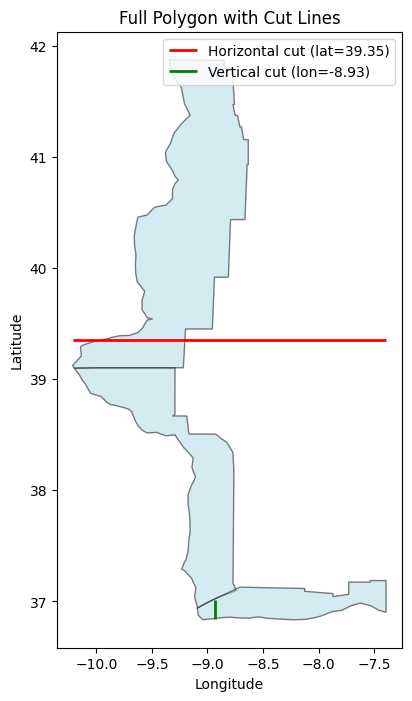

In [10]:
# Plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot full polygon
gdf.plot(ax=ax, facecolor='lightblue', edgecolor='black', alpha=0.5)

# Plot lines
gpd.GeoSeries([line1]).plot(ax=ax, color='red', linewidth=2, label='Horizontal cut (lat=39.35)')
gpd.GeoSeries([line2]).plot(ax=ax, color='green', linewidth=2, label='Vertical cut (lon=-8.93)')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Full Polygon with Cut Lines')
ax.legend()
plt.show()

In [8]:
def build_shape_mask(ds, shapefile):
    """
    Build a boolean mask on the native OISST grid.
    Assumes ds.lon is in 0-360 format.
    """

    gdf = shapefile.to_crs("EPSG:4326")

    # ---- convert shapefile lon from -180..180 → 0..360 ----
    gdf["geometry"] = gdf.geometry.translate(xoff=360)
    gdf["geometry"] = gdf.geometry.buffer(0)

    # grid spacing
    dlat = float(abs(ds.lat[1] - ds.lat[0]))
    dlon = float(abs(ds.lon[1] - ds.lon[0]))

    # raster transform (cell-centered grid)
    transform = from_origin(
        ds.lon.min().item() - dlon / 2,
        ds.lat.max().item() + dlat / 2,
        dlon,
        dlat
    )

    mask = geometry_mask(
        gdf.geometry,
        out_shape=(ds.dims["lat"], ds.dims["lon"]),
        transform=transform,
        invert=True
    )

    # flip latitude to match xarray ordering
    mask = mask[::-1, :]

    return xr.DataArray(
        mask,
        coords={"lat": ds.lat, "lon": ds.lon},
        dims=("lat", "lon")
    )


In [9]:
ref_ds = xr.open_dataset("oisst_daily/sst.day.mean.1982.nc")
shape_masks = {'NW': build_shape_mask(ref_ds, b200_3. iloc[[0]]),
               'SW': build_shape_mask(ref_ds, b200_3.iloc[[1]]),
               'S': build_shape_mask(ref_ds, b200_3.iloc[[2]])}

/var/folders/wq/98_by44j0113pwx7jtjgd74w0000gn/T/ipykernel_34008/8589276.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_shape=(ds.dims["lat"], ds.dims["lon"]),
/var/folders/wq/98_by44j0113pwx7jtjgd74w0000gn/T/ipykernel_34008/8589276.py:27: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_shape=(ds.dims["lat"], ds.dims["lon"]),


IndexError: positional indexers are out-of-bounds

## Get Baseline

Baseline used is 1981-2010

In [ ]:
baseline_df = pd.DataFrame()

for year in range(1982, 2012):

    var = xr.open_dataset(f"oisst_daily/sst.day.mean.{year}.nc", 
                        engine="netcdf4", decode_times=True)
    
    print(f'Opening {year}')
    
    var_sel = spatial_subset(var)
    
    var_sst = var_sel["sst"]

    baseline_df = pd.concat([baseline_df, var_sst.to_dataframe()])

baseline_df.reset_index(inplace= True)   
del var

## Years to Analyse

#### Slice datasets' coordinates

In [ ]:
def treat_year(year, shape_mask):
    oisst = xr.open_dataset(f"oisst_daily/sst.day.mean.{year}.nc", 
                        engine="netcdf4", decode_times=True)
    
    oisst_sel = spatial_subset(oisst).where(shape_mask)
    oisst_sst = oisst_sel["sst"]
    return oisst_sst.to_dataframe().reset_index()

In [ ]:
y2023 = {'NW': treat_year(2023, shape_masks['NW']),
             'SW': treat_year(2023, shape_masks['SW']),
             'S': treat_year(2023, shape_masks['S'])}

## Conversion to ordinal time

In [ ]:
def to_ordinal(time_array):
    ordinals = []

    for t in time_array:
        # Case 1: numpy.datetime64
        if isinstance(t, np.datetime64):
            ts = pd.Timestamp(t)
            ordinals.append(ts.to_pydatetime().date().toordinal())

        # Case 2: cftime objects
        else:
            ordinals.append(dt.date(t.year, t.month, t.day).toordinal())

    return np.array(ordinals)

## Detect MHWs

In [ ]:
def detect_mhw_year(year_df, baseline_df, climatology_period=(1982, 2011)):
    results = []

    for (lat, lon), group_year in year_df.groupby(["lat", "lon"]):

        # --- year data ---
        y_sst = group_year["sst"].values
        y_time = group_year["time"].values
        y_time_ord = to_ordinal(y_time)

        # --- baseline for same grid cell ---
        base_group = baseline_df[
            (baseline_df["lat"] == lat) &
            (baseline_df["lon"] == lon)
        ]

        if base_group.empty:
            continue

        base_sst = base_group["sst"].values
        base_time = base_group["time"].values
        base_time_ord = to_ordinal(base_time)

        base_years = pd.to_datetime(base_time).year

        if (base_years.min() > climatology_period[0] or
            base_years.max() < climatology_period[1]):
            continue

        # --- MHW detection ---
        mhw_ev, clim = mhw.detect(
            y_time_ord,
            y_sst,
            climatologyPeriod= list(climatology_period),
            alternateClimatology= [base_time_ord, base_sst]
        )

        results.append({
            "year": pd.to_datetime(y_time[0]).year,
            "lat": lat,
            "lon": lon,
            "n_events": mhw_ev["n_events"],
            "total_duration": (
                np.sum(mhw_ev["duration"])
            ),
            "max_intensity": (
                np.max(mhw_ev["intensity_max"])
                if mhw_ev["n_events"] > 0 else np.nan
            ),
            "mean_intensity":
                float(np.mean(mhw_ev["intensity_mean"])),
            'cummulative_intensity': 
                np.sum(mhw_ev['intensity_cumulative']),
        })

    return pd.DataFrame(results)


In [ ]:
mhw_2023 = {'NW': detect_mhw_year(y2023['NW'], baseline_df),
             'SW': detect_mhw_year(y2023['SW'], baseline_df),
             'S': detect_mhw_year(y2023['S'], baseline_df)}

In [ ]:
mhw_2023['NW'].agg(['min', 'max', 'mean', 'std']).T

In [ ]:
yearly_dfs = {
    2023: mhw_2023
}

## Graphs

#### By number of events

In [ ]:
# =================================================
# OCEAN MASK (native grid)
# =================================================

ds_plot = spatial_subset(
    xr.open_dataset("oisst_daily/sst.day.mean.2023.nc", decode_times=True)
)

lon = ds_plot.lon.values
lat = ds_plot.lat.values
lon2d, lat2d = np.meshgrid(lon, lat)



fig = plt.figure(figsize=(16, 10))
gs = GridSpec(1, 4, width_ratios=[1,1,1,0.05])

regions = ["NW","SW","S"]
vmax = max(mhw_2023[r]["n_events"].max() for r in regions)

for i, r in enumerate(regions):

    df = mhw_2023[r]

    grid = (
        df.pivot(index="lat", columns="lon", values="n_events")
          .reindex(index=lat, columns=lon)
          .fillna(0)
          .values
    )

    ax = fig.add_subplot(gs[0,i], projection=ccrs.PlateCarree())

    mesh = ax.pcolormesh(
        lon2d, lat2d, grid,
        cmap="hot_r",
        shading="nearest",
        vmin=0, vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()])
    ax.add_feature(cfeature.COASTLINE)
    ax.set_title(f"{r} – Event count")

cax = fig.add_subplot(gs[0,-1])
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Number of MHW events")

plt.show()


#### By total duration

In [ ]:
# =================================================
# OCEAN MASK (native grid)
# =================================================

ds_plot = spatial_subset(
    xr.open_dataset("oisst_daily/sst.day.mean.2023.nc", decode_times=True)
)

lon = ds_plot.lon.values
lat = ds_plot.lat.values
lon2d, lat2d = np.meshgrid(lon, lat)



fig = plt.figure(figsize=(16, 10))
gs = GridSpec(1, 4, width_ratios=[1,1,1,0.05])

regions = ["NW","SW","S"]
vmax = max(mhw_2023[r]["total_duration"].max() for r in regions)

for i, r in enumerate(regions):

    df = mhw_2023[r]

    grid = (
        df.pivot(index="lat", columns="lon", values="total_duration")
          .reindex(index=lat, columns=lon)
          .fillna(0)
          .values
    )

    ax = fig.add_subplot(gs[0,i], projection=ccrs.PlateCarree())

    mesh = ax.pcolormesh(
        lon2d, lat2d, grid,
        cmap="hot_r",
        shading="nearest",
        vmin=0, vmax=vmax,
        transform=ccrs.PlateCarree()
    )

    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()])
    ax.add_feature(cfeature.COASTLINE)
    ax.set_title(f"{r} – MHW days")

cax = fig.add_subplot(gs[0,-1])
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("Total MHW days")

fig.suptitle('Total MHW days - ICES 9a')
plt.show()
